<a href="https://colab.research.google.com/github/melaniebc/01_IntroPython_Buena-oMelanie.ipynb/blob/main/Examen1B_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
from google.colab import files

uploaded = files.upload()

Saving 01 Call-Center-Dataset.xlsx to 01 Call-Center-Dataset (1).xlsx


In [7]:
df = pd.read_excel('01 Call-Center-Dataset.xlsx')

In [8]:
df.head()

,Call Id,Agent,Date,Time,Topic,Answered (Y/N),Resolved,Speed of answer in seconds,AvgTalkDuration,Satisfaction rating
0,ID0001,Diane,2021-01-01,09:12:58,Contract related,Y,Y,109.0,00:02:23,3.0
1,ID0002,Becky,2021-01-01,09:12:58,Technical Support,Y,N,70.0,00:04:02,3.0
2,ID0003,Stewart,2021-01-01,09:47:31,Contract related,Y,Y,10.0,00:02:11,3.0
3,ID0004,Greg,2021-01-01,09:47:31,Contract related,Y,Y,53.0,00:00:37,2.0
4,ID0005,Becky,2021-01-01,10:00:29,Payment related,Y,Y,95.0,00:01:00,3.0


In [9]:
df.columns

Index(['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)',
       'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration',
       'Satisfaction rating'],
      dtype='object')

In [10]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Call Id                     5000 non-null   object 
 1   Agent                       5000 non-null   object 
 2   Date                        5000 non-null   object 
 3   Time                        5000 non-null   object 
 4   Topic                       5000 non-null   object 
 5   Answered (Y/N)              5000 non-null   object 
 6   Resolved                    5000 non-null   object 
 7   Speed of answer in seconds  4054 non-null   float64
 8   AvgTalkDuration             4054 non-null   object 
 9   Satisfaction rating         4054 non-null   float64
dtypes: float64(2), object(8)
memory usage: 390.8+ KB


In [11]:
df['Answered (Y/N)'].unique()

array(['Y', 'N'], dtype=object)

In [12]:
df['Answered (Y/N)'].value_counts()

,count
Answered (Y/N),
Y,4054
N,946


In [13]:
df['Resolved'].unique()

array(['Y', 'N'], dtype=object)

In [14]:
df['Resolved'].value_counts()

,count
Resolved,
Y,3646
N,1354


In [15]:
df[['Answered (Y/N)', 'Resolved']].isnull().sum()

,0
Answered (Y/N),0
Resolved,0


# **ANÁLISIS DE DATOS KPI 1**


Antes de calcular el KPI 1 se realizó una validación de calidad de los datos dados de la base de datos para verificar los valores presentes en las variables "Answered (Y/N)" y "Resolved", también si existe algín valor faltante. Verificado \esto se puede se puede garantizar que el calculo se realiza con valores reales.



# ***KPI 1: Tasa de Resolución en la Llamada (CR - Call Resolution)***

In [18]:

llamadas_atendidas = df[df['Answered (Y/N)'] == 'Y'].shape[0]

llamadas_resueltas = df[df['Resolved'] == 'Y'].shape[0]

cr = (llamadas_resueltas / llamadas_atendidas) * 100

print("Llamadas atendidas:", llamadas_atendidas)
print("Llamadas resueltas:", llamadas_resueltas)
print(f"CR: {cr:.2f}%")

Llamadas atendidas: 4054
Llamadas resueltas: 3646
CR: 89.94%


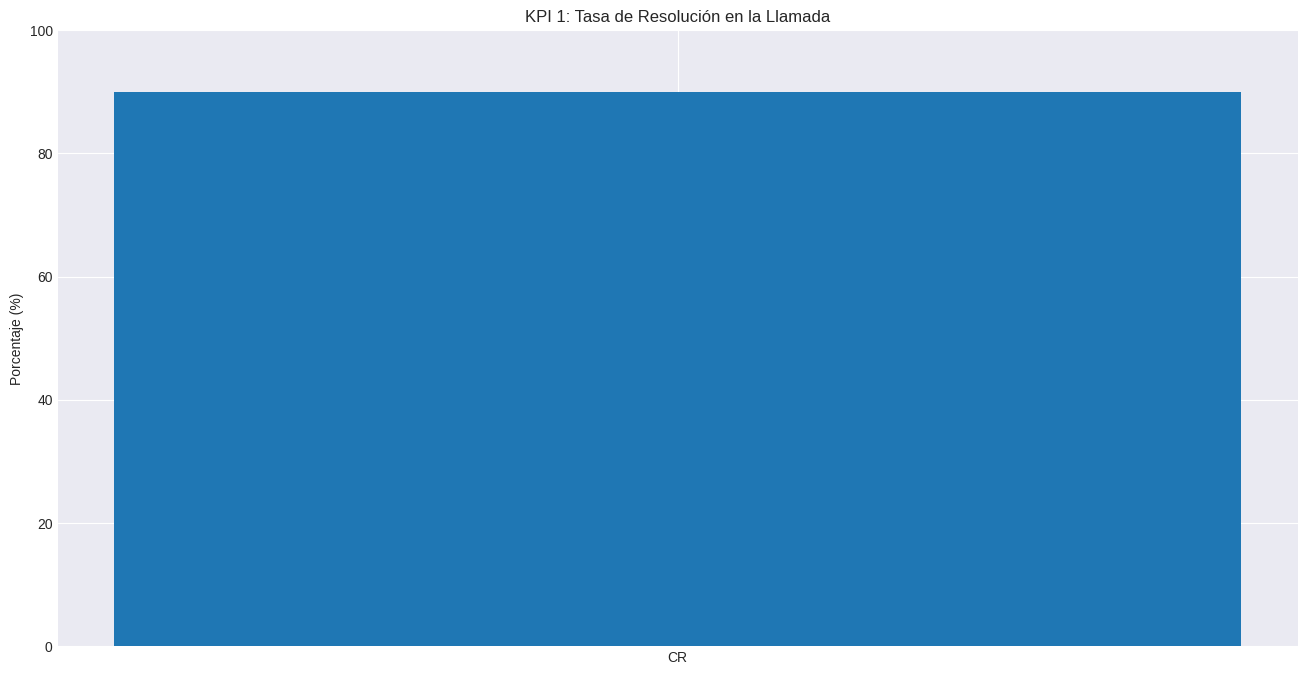

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.bar(['CR'], [cr])

plt.title('KPI 1: Tasa de Resolución en la Llamada')
plt.ylabel('Porcentaje (%)')
plt.ylim(0,100)

plt.show()

# **Resultado e Interpretación**

**Valor obtenido:** CR = 89.94%

**Cálculo:** Se utilizó la fórmula:

CR = (Llamadas Resueltas / Llamadas Atendidas) × 100

Se utilizaron las llamadas atendidas como denominador debido a que únicamente las interacciones gestionadas por un agente pueden ser evaluadas en términos de resolución. El resultado obtenido indica que el 89.94% de las llamadas atendidas fueron resueltas exitosamente.

**Interpretación de negocio:** El resultado muestra que casi 9 de cada 10 llamadas atendidas fueron resueltas. Esto indica que el Call Center tiene una buena capacidad para solucionar los problemas de los clientes durante el primer contacto.

---



In [29]:
df['Speed of answer in seconds'].isnull().sum()

np.int64(946)

In [30]:
df['Speed of answer in seconds'].describe()

,Speed of answer in seconds
count,4054.000000
mean,67.520720
std,33.592872
min,10.000000
25%,39.000000
50%,68.000000
75%,97.000000
max,125.000000


# **Análisis de Datos KPI 2**

Antes de calcular el KPI 2 se realizó una validación de calidad de los datos para verificar la existencia de valores nulos y revisar la distribución de la variable "Speed of answer in seconds", la cual contiene el tiempo de espera de los clientes antes de ser atendidos. Esta verificación garantiza que el cálculo del Tiempo Promedio de Respuesta (ASA) se realice utilizando datos consistentes y confiables.

# ***KPI 2: Tiempo Promedio de Respuesta (ASA - Average Speed of Answer)***

In [31]:
asa = df['Speed of answer in seconds'].mean()

print(f"ASA: {asa:.2f} segundos")

ASA: 67.52 segundos


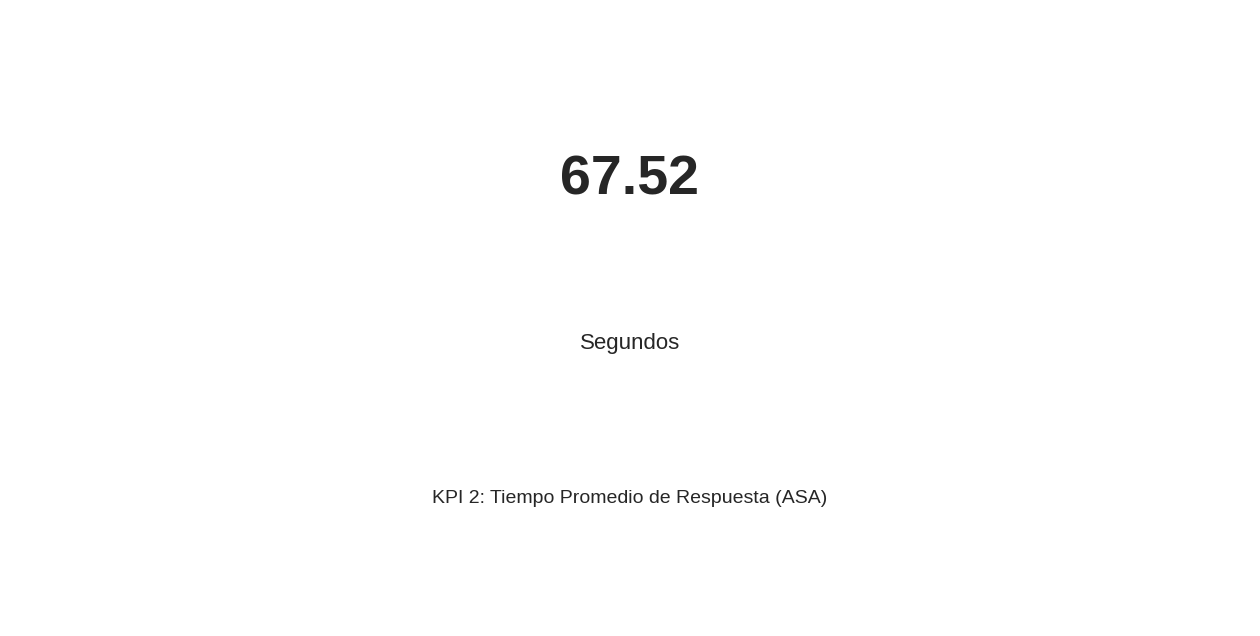

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16,8))

ax.axis('off')

ax.text(
    0.5, 0.7,
    f"{asa:.2f}",
    fontsize=40,
    fontweight='bold',
    ha='center'
)

ax.text(
    0.5, 0.45,
    "Segundos",
    fontsize=16,
    ha='center'
)

ax.text(
    0.5, 0.2,
    "KPI 2: Tiempo Promedio de Respuesta (ASA)",
    fontsize=14,
    ha='center'
)

plt.show()

# **Resultado e Interpretación**

**Valor obtenido:** ASA = 67.52 segundos

**Cálculo:** Se utilizó el promedio de la variable "Speed of answer in seconds", que representa el tiempo que los clientes esperaron antes de ser atendidos.

**Interpretación de negocio:** El resultado muestra que, en promedio, los clientes esperaron 67.52 segundos para ser atendidos. Mientras menor sea este tiempo, más rápida y eficiente es la atención brindada por el Call Center.


---



In [37]:
df['Satisfaction rating'].isnull().sum()

np.int64(946)

In [38]:
df['Satisfaction rating'].value_counts().sort_index()

,count
Satisfaction rating,
1.0,417
2.0,396
3.0,1218
4.0,1180
5.0,843


In [39]:
df['Satisfaction rating'].describe()

,Satisfaction rating
count,4054.000000
mean,3.403552
std,1.212220
min,1.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,5.000000


# **Análisis de Datos KPI 3**

Antes de calcular el KPI 3 se realizó una validación de calidad de los datos para verificar la existencia de valores nulos y revisar los valores registrados en la variable "Satisfaction rating". Esta revisión permitió confirmar que las calificaciones de satisfacción se encuentran disponibles y son adecuadas para calcular el nivel promedio de satisfacción de los clientes.

# ***KPI 3: Nivel de Satisfacción del Cliente (CSAT Promedio)***

In [40]:
csat = df['Satisfaction rating'].mean()

print(f"CSAT Promedio: {csat:.2f}")

CSAT Promedio: 3.40


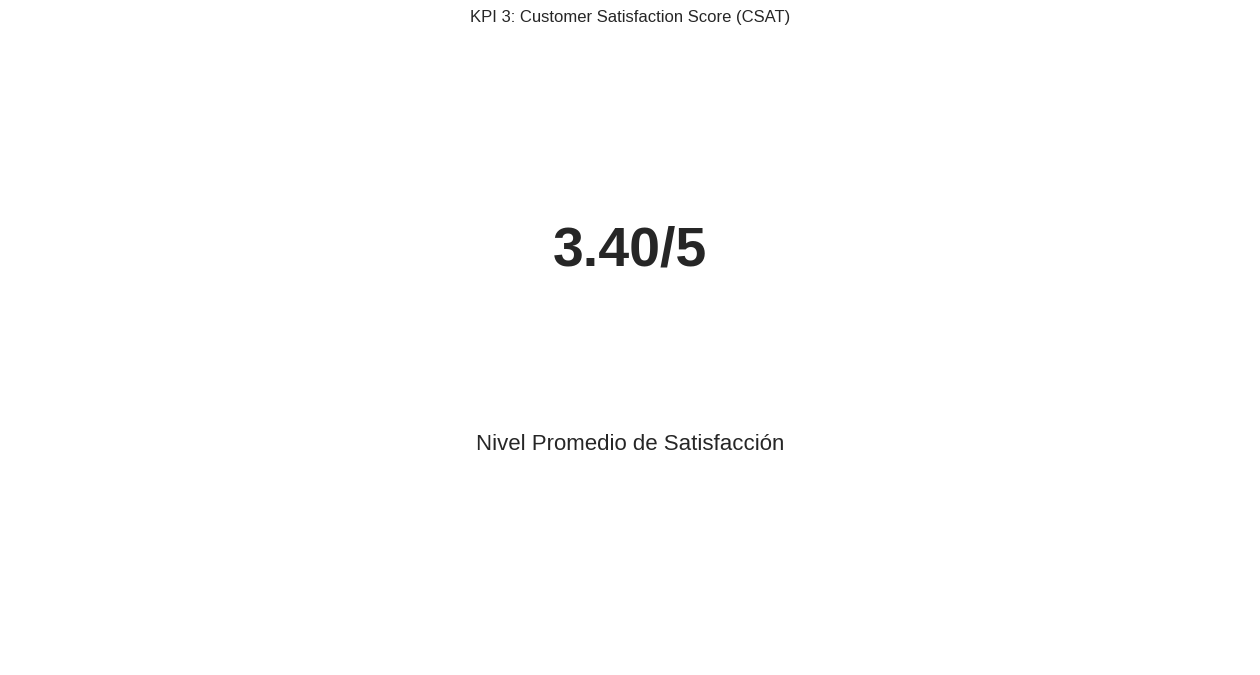

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.axis('off')

plt.text(
    0.5, 0.65,
    f'{csat:.2f}/5',
    fontsize=40,
    fontweight='bold',
    ha='center'
)

plt.text(
    0.5, 0.35,
    'Nivel Promedio de Satisfacción',
    fontsize=16,
    ha='center'
)

plt.title('KPI 3: Customer Satisfaction Score (CSAT)', pad=20)

plt.show()

# **Resultado e Interpretación**

**Valor obtenido:** CSAT = 3.40

**Cálculo:** Se utilizó el promedio de la variable "Satisfaction rating", la cual contiene las calificaciones otorgadas por los clientes después de recibir atención.

**Interpretación de negocio:** El resultado muestra el nivel promedio de satisfacción de los clientes con el servicio recibido. Un valor cercano a 5 indica que los usuarios tuvieron una experiencia positiva y quedaron satisfechos con la atención brindada por el Call Center.


---



In [46]:
df[['Agent','Call Id','Answered (Y/N)']].isnull().sum()

,0
Agent,0
Call Id,0
Answered (Y/N),0


In [47]:
df['Agent'].unique()

array(['Diane', 'Becky', 'Stewart', 'Greg', 'Jim', 'Joe', 'Martha', 'Dan'],
      dtype=object)

# **Análisis de Datos KPI 4**

Antes de calcular el KPI 4 se realizó una validación de calidad de los datos para verificar la existencia de valores nulos y revisar la información contenida en las variables "Agent", "Call Id" y "Answered (Y/N)". Esta revisión permitió garantizar que los cálculos del volumen de llamadas y la tasa de abandono se realicen con datos válidos y consistentes.

# ***KPI 4: Volumen de Llamadas y Tasa de Abandono por Agente***

In [48]:
volumen = df.groupby('Agent')['Call Id'].count().sort_values(ascending=False)

print(volumen)

Agent
Jim        666
Martha     638
Dan        633
Diane      633
Becky      631
Greg       624
Joe        593
Stewart    582
Name: Call Id, dtype: int64


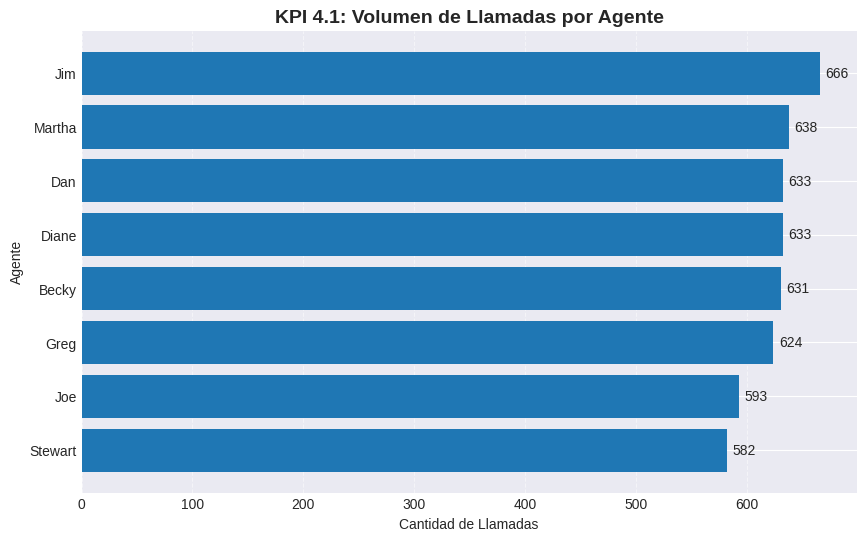

In [53]:
import matplotlib.pyplot as plt

volumen = df.groupby('Agent')['Call Id'].count().sort_values()

plt.figure(figsize=(10,6))

bars = plt.barh(volumen.index, volumen.values)

plt.title('KPI 4.1: Volumen de Llamadas por Agente', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Agente')

plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    ancho = bar.get_width()
    plt.text(
        ancho + 5,
        bar.get_y() + bar.get_height()/2,
        f'{int(ancho)}',
        va='center'
    )

plt.show()

# **Resultado e Interpretación - Volumen de Llamadas por Agente**

**Cálculo:** Se contabilizó el número total de llamadas gestionadas por cada agente utilizando la variable "Call Id".

**Interpretación de negocio:** Este indicador permite identificar qué agentes tienen una mayor carga de trabajo dentro del Call Center. Un volumen elevado de llamadas puede reflejar una alta demanda de atención o una distribución desigual de las tareas entre los agentes.


In [56]:
abandono = df.groupby('Agent')['Answered (Y/N)'].apply(
    lambda x: (x == 'N').sum()/len(x)*100
).sort_values(ascending=False)

print(abandono)

Agent
Diane      20.853081
Greg       19.551282
Jim        19.519520
Martha     19.435737
Joe        18.381113
Becky      18.066561
Stewart    18.041237
Dan        17.377567
Name: Answered (Y/N), dtype: float64


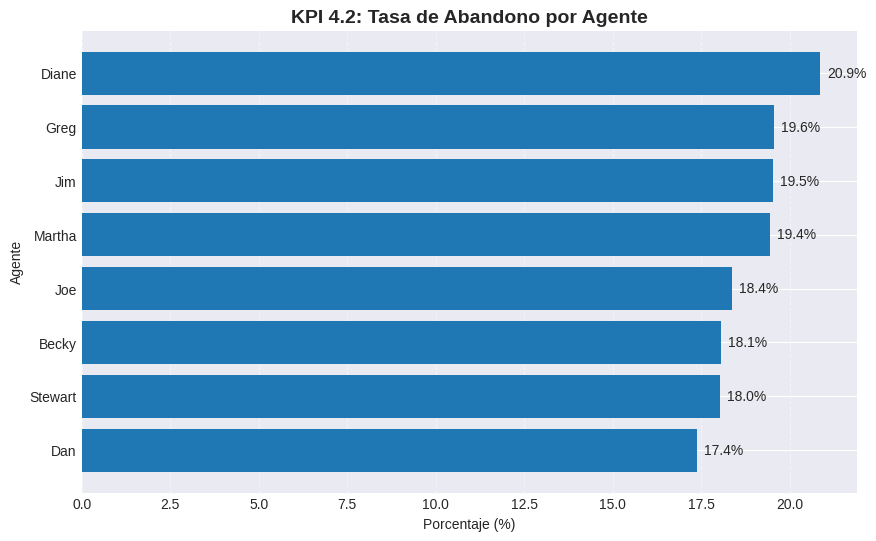

In [55]:
import matplotlib.pyplot as plt

abandono = df.groupby('Agent')['Answered (Y/N)'].apply(
    lambda x: (x == 'N').sum()/len(x)*100
).sort_values()

plt.figure(figsize=(10,6))

bars = plt.barh(abandono.index, abandono.values)

plt.title('KPI 4.2: Tasa de Abandono por Agente', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Agente')

plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    ancho = bar.get_width()
    plt.text(
        ancho + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{ancho:.1f}%',
        va='center'
    )

plt.show()

# **Resultado e Interpretación - Tasa de Abandono por Agente**

**Cálculo:** Se calculó el porcentaje de llamadas no atendidas respecto al total de llamadas asignadas a cada agente.

**Interpretación de negocio:** Este indicador permite identificar agentes o áreas donde existe una mayor cantidad de llamadas perdidas. Una tasa de abandono alta puede afectar la satisfacción de los clientes y señalar la necesidad de mejorar la asignación de recursos o los tiempos de respuesta.


---


